### Import danych

In [120]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import textwrap

In [121]:
df_waw = pd.read_csv("data/warszawa-gus-bdl.csv", delimiter=";")
df_krk = pd.read_csv("data/krakow-gus-bdl.csv", delimiter=";")
df_wrc = pd.read_csv("data/wroclaw-gus-bdl.csv", delimiter=";")

WARSAW_AREA = 517.24
KRAKOW_AREA = 327.00
WROCLAW_AREA = 293.00

In [122]:
df_waw.columns

Index(['Kategoria', 'Grupa', 'Podgrupa (wymiary)', 'Wymiar 1', 'Wymiar 2',
       'Wymiar 3', 'Wymiar 4', 'Wymiar 5', 'Jednostka miary', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025',
       'Unnamed: 19'],
      dtype='str')

In [123]:
# print all unique categories and it's groups and it's Podgrupa (wymiary)

pg_count_waw = df_waw['Podgrupa (wymiary)'].nunique()
pg_count_krk = df_krk['Podgrupa (wymiary)'].nunique()
pg_count_wrc = df_wrc['Podgrupa (wymiary)'].nunique()
print(f"Number of unique Podgrupa (wymiary): {pg_count_waw} (Warszawa), {pg_count_krk} (Kraków)", f"{pg_count_wrc} (Wrocław)")

mutual_pg = set(df_waw['Podgrupa (wymiary)']).intersection(set(df_krk['Podgrupa (wymiary)']))
print(f"Number of mutual Podgrupa (wymiary): {len(mutual_pg)}")
unique_pg_waw = set(df_waw['Podgrupa (wymiary)']).difference(set(df_krk['Podgrupa (wymiary)']))
print(f"Number of unique Podgrupa (wymiary) in Warszawa: {len(unique_pg_waw)}")
print(f"Unique Podgrupa (wymiary) in Warszawa: {unique_pg_waw}")
unique_pg_krk = set(df_krk['Podgrupa (wymiary)']).difference(set(df_waw['Podgrupa (wymiary)']))
print(f"Number of unique Podgrupa (wymiary) in Kraków: {len(unique_pg_krk)}")
print(f"Unique Podgrupa (wymiary) in Kraków: {unique_pg_krk}")
unique_pg_wrc = set(df_wrc['Podgrupa (wymiary)']).difference(set(df_waw['Podgrupa (wymiary)'])).difference(set(df_krk['Podgrupa (wymiary)']))
print(f"Number of unique Podgrupa (wymiary) in Wrocław: {len(unique_pg_wrc)}")
print(f"Unique Podgrupa (wymiary) in Wrocław: {unique_pg_wrc}")

for cat in df_waw['Kategoria'].unique():
    print(f"Kategoria: {cat}")
    for group in df_waw[df_waw['Kategoria'] == cat]['Grupa'].unique():
        print(f"  Grupa: {group}")
        for podgrupa in df_waw[(df_waw['Kategoria'] == cat) & (df_waw['Grupa'] == group)]['Podgrupa (wymiary)'].unique():
            print(f"    Podgrupa: {podgrupa}")
            for w in df_waw[(df_waw['Kategoria'] == cat) & (df_waw['Grupa'] == group) & (df_waw['Podgrupa (wymiary)'] == podgrupa)]['Wymiar 1'].unique():
                print(f"      Wymiar: {w}")

Number of unique Podgrupa (wymiary): 232 (Warszawa), 231 (Kraków) 226 (Wrocław)
Number of mutual Podgrupa (wymiary): 226
Number of unique Podgrupa (wymiary) in Warszawa: 6
Unique Podgrupa (wymiary) in Warszawa: {'Przewozy ładunków morską flotą transportową według relacji (Wymiary: Przewozy ładunków)', 'Osady dotychczas składowane (nagromadzone) na terenie oczyszczalni i wykorzystane z dotychczas składowanych (Wymiary: Osady)', 'Morska flota transportowa (Wymiary: Liczba statków / nośność; Rodzaje statków)', 'Mieszkania w budynkach (gminnych) zwrócone dawnym indywidualnym właścicielom bądź spadkobiercom (Wymiary: Budynki/mieszkania/powierzchnia)', 'Zasoby mieszkaniowe gmin (komunalne) wynajmowane od innych podmiotów (Wymiary: Rodzaje zasobów mieszkaniowych; Zasoby mieszkaniowe)', 'Przewozy ładunków morską flotą transportową według rodzajów żeglugi i zasięgu pływania (Wymiary: Żegluga; Zasięg)'}
Number of unique Podgrupa (wymiary) in Kraków: 5
Unique Podgrupa (wymiary) in Kraków: {'Powie

In [124]:
def get_series(df, cat, group, subgroup, w1='', w2='', w3='', w4='', w5='') -> pd.Series:
    mask = (
        (df['Kategoria'] == cat) &
        (df['Grupa'] == group) &
        (df['Podgrupa (wymiary)'] == subgroup) &
        (df['Wymiar 1'].fillna('') == w1) &
        (df['Wymiar 2'].fillna('') == w2) &
        (df['Wymiar 3'].fillna('') == w3) &
        (df['Wymiar 4'].fillna('') == w4) &
        (df['Wymiar 5'].fillna('') == w5)
    )
    row = df[mask]
    
    if row.empty:
        print("No matching row found.")
        
    years = [str(yr) for yr in range(2016, 2026)]
    series = row.iloc[0][years].str.replace(',', '.').astype(float)
    
    return series

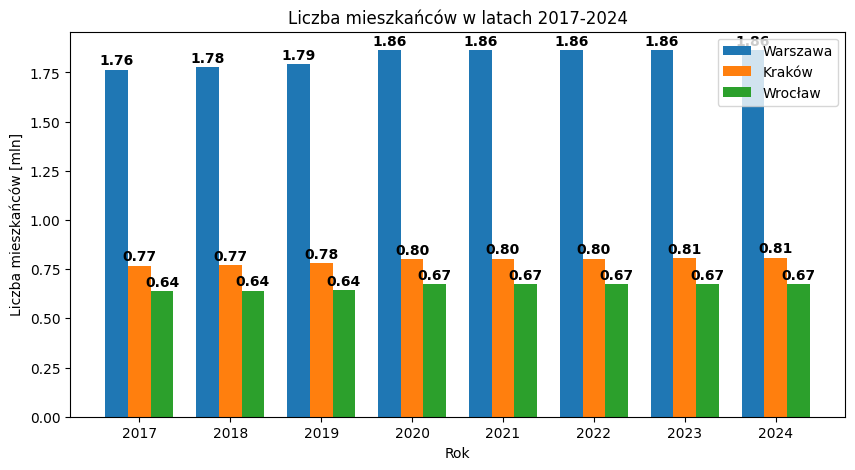

In [125]:
people_loc = ["LUDNOŚĆ","STAN LUDNOŚCI","Ludność wg grup wieku i płci (Wymiary: Wiek; Płeć)","ogółem","ogółem"]
people_waw = get_series(df_waw, *people_loc)[1:].dropna()
people_krk = get_series(df_krk, *people_loc)[1:].dropna()
people_wrc = get_series(df_wrc, *people_loc)[1:].dropna()

bar_width = 0.25
index = np.arange(len(people_waw))

plt.figure(figsize=(10, 5))
plt.bar(index, people_waw.values / 1e6, bar_width, label='Warszawa')
plt.bar(index + bar_width, people_krk.values / 1e6, bar_width, label='Kraków')
plt.bar(index + 2 * bar_width, people_wrc.values / 1e6, bar_width, label='Wrocław')
plt.xticks(index + bar_width, people_waw.index)
# add bold number labels stick to top of bars
for i in range(len(people_waw)):
    plt.text(index[i], people_waw.values[i] / 1e6 + 0.01, f"{people_waw.values[i]/1e6:,.2f}", ha='center', va='bottom', fontweight='bold')
    plt.text(index[i] + bar_width, people_krk.values[i] / 1e6 + 0.01, f"{people_krk.values[i]/1e6:,.2f}", ha='center', va='bottom', fontweight='bold')
    plt.text(index[i] + 2 * bar_width, people_wrc.values[i] / 1e6 + 0.01, f"{people_wrc.values[i]/1e6:,.2f}", ha='center', va='bottom', fontweight='bold')
plt.title('Liczba mieszkańców w latach 2017-2024')
plt.ylabel('Liczba mieszkańców [mln]')
plt.xlabel('Rok')
plt.legend()
plt.savefig('img/population_comparison.png')

### Wskaźnik jakosci życia

In [126]:
waw_person_data = {}
krk_person_data = {}
wrc_person_data = {}

In [127]:
months = ['styczeń', 'luty', 'marzec', 'kwiecień', 'maj', 'czerwiec', 'lipiec', 'sierpień', 'wrzesień', 'październik', 'listopad', 'grudzień']
median_salaries_waw_24 = 0
median_salaries_krk_24 = 0
median_salaries_wrc_24 = 0
for month in months:
    salaries_loc = ["WYNAGRODZENIA I ŚWIADCZENIA SPOŁECZNE","WYNAGRODZENIA","Mediana wynagrodzeń miesięcznych brutto według badania Rozkład wynagrodzeń w gospodarce narodowej (Wymiary: Miesiące; Zakres przedmiotowy; Płeć)", month, "wg miejsca zamieszkania", "ogółem"]
    median_salaries_waw_24 += get_series(df_waw, *salaries_loc).values[-2] / 12 # 2024
    median_salaries_krk_24 += get_series(df_krk, *salaries_loc).values[-2] / 12 # 2024
    median_salaries_wrc_24 += get_series(df_wrc, *salaries_loc).values[-2] / 12 # 2024

waw_person_data['Mediana wynagrodzeń miesięcznych brutto [zl]'] = [round(median_salaries_waw_24, 2), True]
krk_person_data['Mediana wynagrodzeń miesięcznych brutto [zl]'] = [round(median_salaries_krk_24, 2), True]
wrc_person_data['Mediana wynagrodzeń miesięcznych brutto [zl]'] = [round(median_salaries_wrc_24, 2), True]
print(f"Średnia mediana wynagrodzeń miesięcznych brutto w 2024 roku: {median_salaries_waw_24:.2f} PLN (Warszawa), {median_salaries_krk_24:.2f} PLN (Kraków), {median_salaries_wrc_24:.2f} PLN (Wrocław)")

Średnia mediana wynagrodzeń miesięcznych brutto w 2024 roku: 8958.06 PLN (Warszawa), 7985.85 PLN (Kraków), 7860.04 PLN (Wrocław)


In [128]:
m2_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "ZASOBY MIESZKANIOWE", "Zasoby mieszkaniowe - wskaźniki (Wymiary: Wskaźniki)", "przeciętna powierzchnia użytkowa mieszkania na 1 osobę"]
waw_person_data['Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]'] = [get_series(df_waw, *m2_loc).values[-2], True]
krk_person_data['Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]'] = [get_series(df_krk, *m2_loc).values[-2], True]
wrc_person_data['Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]'] = [get_series(df_wrc, *m2_loc).values[-2], True]

unemployment_loc = ["RYNEK PRACY","BEZROBOCIE REJESTROWANE","Udział bezrobotnych zarejestrowanych w liczbie ludności w wieku produkcyjnym wg płci (Wymiary: Płeć)","ogółem"]
waw_person_data['Udział bezrobotnych w wieku produkcyjnym [%]'] = [get_series(df_waw, *unemployment_loc).values[-2], False]
krk_person_data['Udział bezrobotnych w wieku produkcyjnym [%]'] = [get_series(df_krk, *unemployment_loc).values[-2], False]
wrc_person_data['Udział bezrobotnych w wieku produkcyjnym [%]'] = [get_series(df_wrc, *unemployment_loc).values[-2], False]

nursery_loc = ["OCHRONA ZDROWIA, OPIEKA SPOŁECZNA I ŚWIADCZENIA NA RZECZ RODZINY", "OPIEKA NAD DZIEĆMI W WIEKU DO LAT 3.  ŻŁOBKI", "Żłobki i kluby dziecięce - wskaźniki (Wymiary: Wskaźniki)", "dzieci w żłobkach i klubach dziecięcych na 1000 dzieci w wieku do lat 3"]
waw_person_data['Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]'] = [get_series(df_waw, *nursery_loc).values[-2], True]
krk_person_data['Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]'] = [get_series(df_krk, *nursery_loc).values[-2], True]
wrc_person_data['Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]'] = [get_series(df_wrc, *nursery_loc).values[-2], True]

pharmacy_loc = ["OCHRONA ZDROWIA, OPIEKA SPOŁECZNA I ŚWIADCZENIA NA RZECZ RODZINY", "APTEKI I PUNKTY APTECZNE", "Apteki ogólnodostępne - wskaźniki (Wymiary: Wskaźniki)", "ludność na aptekę ogólnodostępną"]
waw_person_data['Ludność na aptekę ogólnodostępną [os.]'] = [get_series(df_waw, *pharmacy_loc).values[-2], False]
krk_person_data['Ludność na aptekę ogólnodostępną [os.]'] = [get_series(df_krk, *pharmacy_loc).values[-2], False]
wrc_person_data['Ludność na aptekę ogólnodostępną [os.]'] = [get_series(df_wrc, *pharmacy_loc).values[-2], False]

supermarket_loc = ["HANDEL I GASTRONOMIA", "SKLEPY I STACJE PALIW", "Sklepy wg form organizacyjnych (Wymiary: Formy organizacyjne)", "supermarkety"]
waw_person_data['Ludność na supermarket [os.]'] = [(people_waw['2024']/get_series(df_waw, *supermarket_loc)).round(2).values[-2], False]
krk_person_data['Ludność na supermarket [os.]'] = [(people_krk['2024']/get_series(df_krk, *supermarket_loc)).round(2).values[-2], False]
wrc_person_data['Ludność na supermarket [os.]'] = [(people_wrc['2024']/get_series(df_wrc, *supermarket_loc)).round(2).values[-2], False]

green_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Tereny zieleni - wskaźniki (Wymiary: Wskaźniki)", "powierzchnia gminnych terenów zieleni na 1 mieszkańca"]
waw_person_data['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = [get_series(df_waw, *green_areas_loc).values[-2], True]
krk_person_data['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = [get_series(df_krk, *green_areas_loc).values[-2], True]
wrc_person_data['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = [get_series(df_wrc, *green_areas_loc).values[-2], True]

bike_bus_lanes_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "DROGI DLA ROWERÓW", "Długość dróg dla rowerów (Wymiary: Drogi dla rowerów i buspasy)", "drogi dla rowerów na 10 tys. km2"]
waw_person_data['Drogi dla rowerów na km2 [km]'] = [round(get_series(df_waw, *bike_bus_lanes_loc).values[-2]/10000, 2), True]
krk_person_data['Drogi dla rowerów na km2 [km]'] = [round(get_series(df_krk, *bike_bus_lanes_loc).values[-2]/10000, 2), True]
wrc_person_data['Drogi dla rowerów na km2 [km]'] = [round(get_series(df_wrc, *bike_bus_lanes_loc).values[-2]/10000, 2), True]

road_accidents_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "WYPADKI DROGOWE", "Wypadki drogowe i ich ofiary - wskaźniki (Wymiary: Wskaźniki)", "wypadki drogowe na 1000 ludności"]
waw_person_data['Wypadki drogowe na 1000 ludności [l.]'] = [get_series(df_waw, *road_accidents_loc).values[-2], False]
krk_person_data['Wypadki drogowe na 1000 ludności [l.]'] = [get_series(df_krk, *road_accidents_loc).values[-2], False]
wrc_person_data['Wypadki drogowe na 1000 ludności [l.]'] = [get_series(df_wrc, *road_accidents_loc).values[-2], False]

public_transport_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "KOMUNIKACJA MIEJSKA", "Czynne przystanki (Wymiary: Przystanki; Wyszczególnienie)", "ogółem (przystanki autobusowe (z trolejbusowymi) i tramwajowe, przystanki wspólne dla tramwajów i autobusów)", "ogółem"]
waw_person_data['Czynne przystanki komunikacji miejskiej na 1 km2 [l.]'] = [round(get_series(df_waw, *public_transport_loc).values[-2]/WARSAW_AREA, 2), True]
krk_person_data['Czynne przystanki komunikacji miejskiej na 1 km2 [l.]'] = [round(get_series(df_krk, *public_transport_loc).values[-2]/KRAKOW_AREA, 2), True]
wrc_person_data['Czynne przystanki komunikacji miejskiej na 1 km2 [l.]'] = [round(get_series(df_wrc, *public_transport_loc).values[-2]/WROCLAW_AREA, 2), True]

In [129]:
print("Dane dla Warszawy:")
for key, value in waw_person_data.items():
    print(f"{key}: {value}")

print("\nDane dla Krakowa:")
for key, value in krk_person_data.items():
    print(f"{key}: {value}")

print("\nDane dla Wrocławia:")
for key, value in wrc_person_data.items():
    print(f"{key}: {value}")

Dane dla Warszawy:
Mediana wynagrodzeń miesięcznych brutto [zl]: [np.float64(8958.06), True]
Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]: [np.float64(34.5), True]
Udział bezrobotnych w wieku produkcyjnym [%]: [np.float64(1.7), False]
Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]: [np.float64(323.0), True]
Ludność na aptekę ogólnodostępną [os.]: [np.float64(3192.0), False]
Ludność na supermarket [os.]: [np.float64(5481.9), False]
Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]: [np.float64(7.8), True]
Drogi dla rowerów na km2 [km]: [np.float64(1.57), True]
Wypadki drogowe na 1000 ludności [l.]: [np.float64(0.37), False]
Czynne przystanki komunikacji miejskiej na 1 km2 [l.]: [np.float64(8.47), True]

Dane dla Krakowa:
Mediana wynagrodzeń miesięcznych brutto [zl]: [np.float64(7985.86), True]
Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]: [np.float64(33.4), True]
Udział bezrobotnych w wieku produkcyjnym [%]: [np.float64(2.2), False]
Dzieci w żłobk

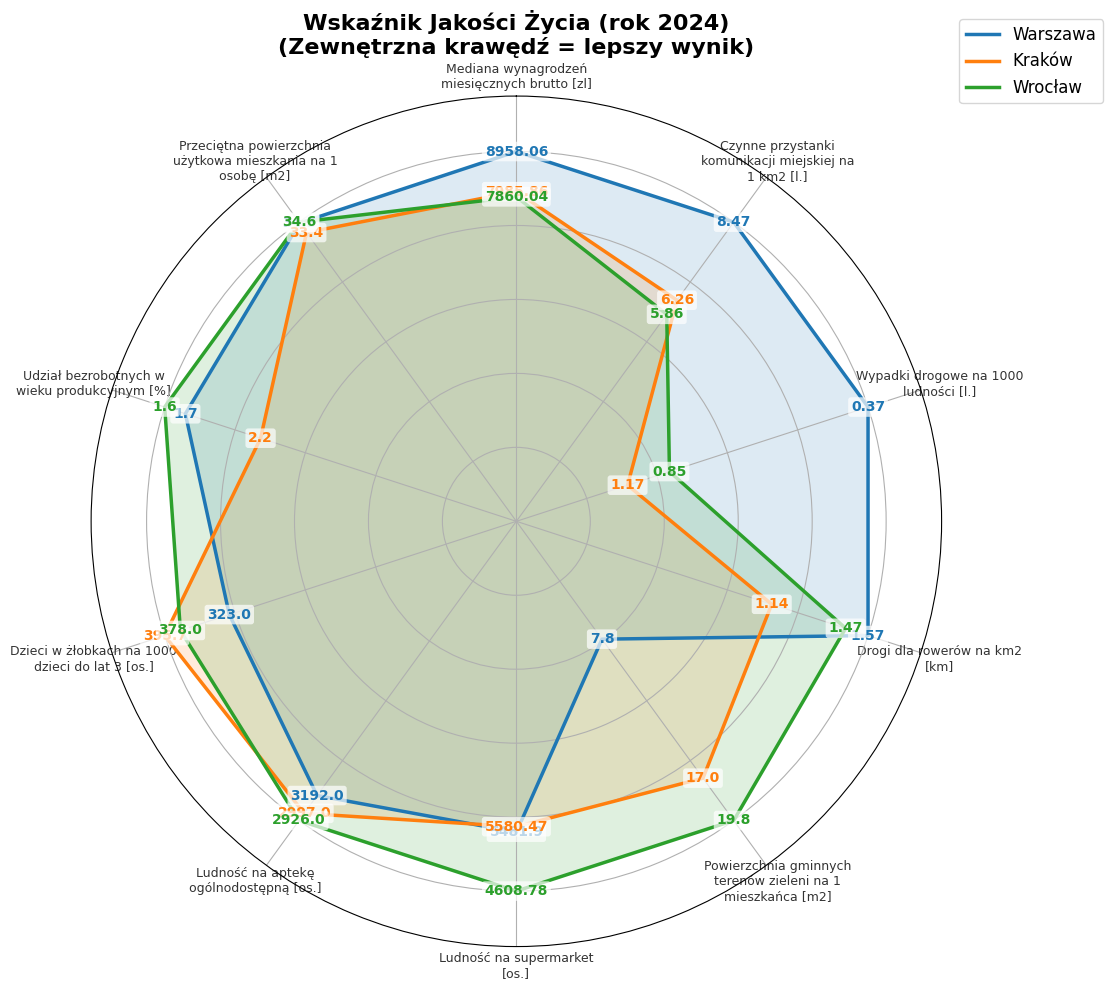

In [139]:
categories = list(waw_person_data.keys())
N = len(categories)
wrapped_labels = [textwrap.fill(cat, width=25) for cat in categories]

# Data normalization for radar chart
waw_scores = []
krk_scores = []
wrc_scores = []

for cat in categories:
    val_waw, more_better = waw_person_data[cat]
    val_krk, _ = krk_person_data[cat]
    val_wrc, _ = wrc_person_data[cat]
    
    if more_better:
        max_val = max(val_waw, val_krk, val_wrc)
        waw_scores.append((val_waw / max_val) * 100)
        krk_scores.append((val_krk / max_val) * 100)
        wrc_scores.append((val_wrc / max_val) * 100)
    else:
        min_val = min(val_waw, val_krk, val_wrc)
        waw_scores.append((min_val / val_waw) * 100)
        krk_scores.append((min_val / val_krk) * 100)
        wrc_scores.append((min_val / val_wrc) * 100)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
waw_scores += waw_scores[:1]
krk_scores += krk_scores[:1]
wrc_scores += wrc_scores[:1]

fig, ax = plt.subplots(figsize=(11, 10), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2) 

plt.xticks(angles[:-1], wrapped_labels, color='#333333', size=9)

ax.set_yticklabels([])
plt.ylim(0, 115)

color_waw = '#1f77b4'
color_krk = '#ff7f0e'
color_wrc='#2ca02c'

ax.plot(angles, waw_scores, linewidth=2.5, linestyle='solid', label='Warszawa', color=color_waw)
ax.fill(angles, waw_scores, color_waw, alpha=0.15)

ax.plot(angles, krk_scores, linewidth=2.5, linestyle='solid', label='Kraków', color=color_krk)
ax.fill(angles, krk_scores, color_krk, alpha=0.15)

ax.plot(angles, wrc_scores, linewidth=2.5, linestyle='solid', label='Wrocław', color='#2ca02c')
ax.fill(angles, wrc_scores, color_wrc, alpha=0.15)

for i in range(N):
    angle_rad = angles[i]
    
    val_waw = waw_person_data[categories[i]][0]
    val_krk = krk_person_data[categories[i]][0]
    val_wrc = wrc_person_data[categories[i]][0]
    
    bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    
    ax.text(angle_rad, waw_scores[i], f"{val_waw}", 
            color=color_waw, size=10, weight='bold',
            ha='center', va='center', bbox=bbox_props)
    
    ax.text(angle_rad, krk_scores[i], f"{val_krk}", 
            color=color_krk, size=10, weight='bold',
            ha='center', va='center', bbox=bbox_props)
    
    ax.text(angle_rad, wrc_scores[i], f"{val_wrc}", 
            color=color_wrc, size=10, weight='bold',
            ha='center', va='center', bbox=bbox_props)

plt.title('Wskaźnik Jakości Życia (rok 2024)\n(Zewnętrzna krawędź = lepszy wynik)', 
          size=16, weight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

fig.tight_layout()
plt.savefig('img/quality_indicator.png', dpi=300)
plt.show()

### Dbałość mieszkańców o środowisko

In [131]:
metrics = {}
water_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "ogółem", "woda z wodociągów", "na 1 mieszkańca"]
metrics['Zużycie wody [m³/os]'] = {
    'WAW': get_series(df_waw, *water_usage_loc).dropna(),
    'KRK': get_series(df_krk, *water_usage_loc).dropna(),
    'WRC': get_series(df_wrc, *water_usage_loc).dropna(),
    'Positive': False,
}
gas_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "ogółem", "gaz z sieci w kWh", "na 1 mieszkańca"]
metrics['Zużycie energii w gosp. dom. [kWh/os]'] = {
    'WAW': get_series(df_waw, *gas_usage_loc).dropna(),
    'KRK': get_series(df_krk, *gas_usage_loc).dropna(),
    'WRC': get_series(df_wrc, *gas_usage_loc).dropna(),
    'Positive': False,
}
electricity_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "w miastach", "energia elektryczna w miastach", "na 1 mieszkańca"]
metrics['Zużycie prądu w gosp. dom. [kWh/os]'] = {
    'WAW': get_series(df_waw, *electricity_usage_loc).dropna(),
    'KRK': get_series(df_krk, *electricity_usage_loc).dropna(),
    'WRC': get_series(df_wrc, *electricity_usage_loc).dropna(),
    'Positive': False,
}
new_trees_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Nasadzenia i ubytki wg lokalizacji w gminach (Wymiary: Prace leśne; Drzewa i krzewy; Lokalizacje)", "nasadzenia", "drzewa", "ogółem (w miastach i na wsi)"]
metrics['Skumulowana liczba nowych drzew na 1km2 [szt.]'] = {
    'WAW': get_series(df_waw, *new_trees_loc).dropna().div(WARSAW_AREA).round(2).cumsum(),
    'KRK': get_series(df_krk, *new_trees_loc).dropna().div(KRAKOW_AREA).round(2).cumsum(),
    'WRC': get_series(df_wrc, *new_trees_loc).dropna().div(WROCLAW_AREA).round(2).cumsum(),
    'Positive': True,
}
new_bushes_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Nasadzenia i ubytki wg lokalizacji w gminach (Wymiary: Prace leśne; Drzewa i krzewy; Lokalizacje)", "nasadzenia", "krzewy", "ogółem (w miastach i na wsi)"]
metrics['Skumulowana liczba nowych krzewów na 1km2 [szt.]'] = {
    'WAW': get_series(df_waw, *new_bushes_loc).dropna().div(WARSAW_AREA).round(2).cumsum(),
    'KRK': get_series(df_krk, *new_bushes_loc).dropna().div(KRAKOW_AREA).round(2).cumsum(),
    'WRC': get_series(df_wrc, *new_bushes_loc).dropna().div(WROCLAW_AREA).round(2).cumsum(),
    'Positive': True,
}
green_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Tereny zieleni - wskaźniki (Wymiary: Wskaźniki)", "powierzchnia gminnych terenów zieleni na 1 mieszkańca"]
metrics['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = {
    'WAW': get_series(df_waw, *green_areas_loc).dropna(),
    'KRK': get_series(df_krk, *green_areas_loc).dropna(),
    'WRC': get_series(df_wrc, *green_areas_loc).dropna(),
    'Positive': True,
}
seletive_rubbish_loc = ["STAN I OCHRONA ŚRODOWISKA", "ODPADY KOMUNALNE", "Odpady zebrane selektywnie w relacji do ogółu odpadów (Wymiary: Ogółem)", "z gospodarstw domowych"]
metrics['Procent odpadów zebranych selektywnie [%]'] = {
    'WAW': get_series(df_waw, *seletive_rubbish_loc).dropna(),
    'KRK': get_series(df_krk, *seletive_rubbish_loc).dropna(),
    'WRC': get_series(df_wrc, *seletive_rubbish_loc).dropna(),
    'Positive': True,
}
communal_rubbish_created_loc = ["STAN I OCHRONA ŚRODOWISKA", "ODPADY KOMUNALNE", "Odpady komunalne wytworzone w ciągu roku (Wymiary: Pochodzenie odpadów)", "z gospodarstw domowych"]
metrics['Odpady komunalne z gospodarstw domowych na 1 mieszkańca [kg]'] = {
    'WAW': get_series(df_waw, *communal_rubbish_created_loc).dropna().div(people_waw / 1000).round(2),
    'KRK': get_series(df_krk, *communal_rubbish_created_loc).dropna().div(people_krk / 1000).round(2),
    'WRC': get_series(df_wrc, *communal_rubbish_created_loc).dropna().div(people_wrc / 1000).round(2),
    'Positive': False,
}
law_protected_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCHRONA PRZYRODY I RÓŻNORODNOŚCI BIOLOGICZNEJ", "Obszary prawnie chronione - wskaźniki (Wymiary: Wskaźniki)", "udział obszarów prawnie chronionych w powierzchni ogółem"]
metrics['Obszary zielone chronione prawem względem powierzchni ogółem [%]'] = {
    'WAW': get_series(df_waw, *law_protected_areas_loc).dropna(),
    'KRK': get_series(df_krk, *law_protected_areas_loc).dropna(),
    'WRC': get_series(df_wrc, *law_protected_areas_loc).dropna(),
    'Positive': True
}
collected_sewage_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCZYSZCZANIE ŚCIEKÓW KOMUNALNYCH", "Ścieki oczyszczane w ciągu roku (Wymiary: Rodzaje ścieków)", "odprowadzone ogółem"]
filtered_collected_sewage_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCZYSZCZANIE ŚCIEKÓW KOMUNALNYCH", "Ścieki oczyszczane w ciągu roku (Wymiary: Rodzaje ścieków)", "oczyszczane razem"]
metrics['Udział ścieków oczyszczanych w stosunku do odprowadzonych [%]'] = {
    'WAW': get_series(df_waw, *filtered_collected_sewage_loc).dropna().div(get_series(df_waw, *collected_sewage_loc).dropna()).mul(100).round(2),
    'KRK': get_series(df_krk, *filtered_collected_sewage_loc).dropna().div(get_series(df_krk, *collected_sewage_loc).dropna()).mul(100).round(2),
    'WRC': get_series(df_wrc, *filtered_collected_sewage_loc).dropna().div(get_series(df_wrc, *collected_sewage_loc).dropna()).mul(100).round(2),
    'Positive': True
}


In [132]:
# shorten data to years 2017-2024 (from mixed 2016/17-2024)
allowed_years = np.arange(2017, 2025).astype(str)
for key in metrics.keys():
    metrics[key]['WAW'] = metrics[key]['WAW'][metrics[key]['WAW'].index.isin(allowed_years)]
    metrics[key]['KRK'] = metrics[key]['KRK'][metrics[key]['KRK'].index.isin(allowed_years)]
    metrics[key]['WRC'] = metrics[key]['WRC'][metrics[key]['WRC'].index.isin(allowed_years)]

In [133]:
for name, values in metrics.items():
    print(f"{name}:")
    # print(f"Metric: {name}, len: {len(values['WAW'])}, {len(values['KRK'])}, {len(values['WRC'])}")
    # print(f"WAW: {values['WAW'].index}")
    # print(f"KRK: {values['KRK'].index}")
    # print(f"WRC: {values['WRC'].index}")

Zużycie wody [m³/os]:
Zużycie energii w gosp. dom. [kWh/os]:
Zużycie prądu w gosp. dom. [kWh/os]:
Skumulowana liczba nowych drzew na 1km2 [szt.]:
Skumulowana liczba nowych krzewów na 1km2 [szt.]:
Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]:
Procent odpadów zebranych selektywnie [%]:
Odpady komunalne z gospodarstw domowych na 1 mieszkańca [kg]:
Obszary zielone chronione prawem względem powierzchni ogółem [%]:
Udział ścieków oczyszczanych w stosunku do odprowadzonych [%]:


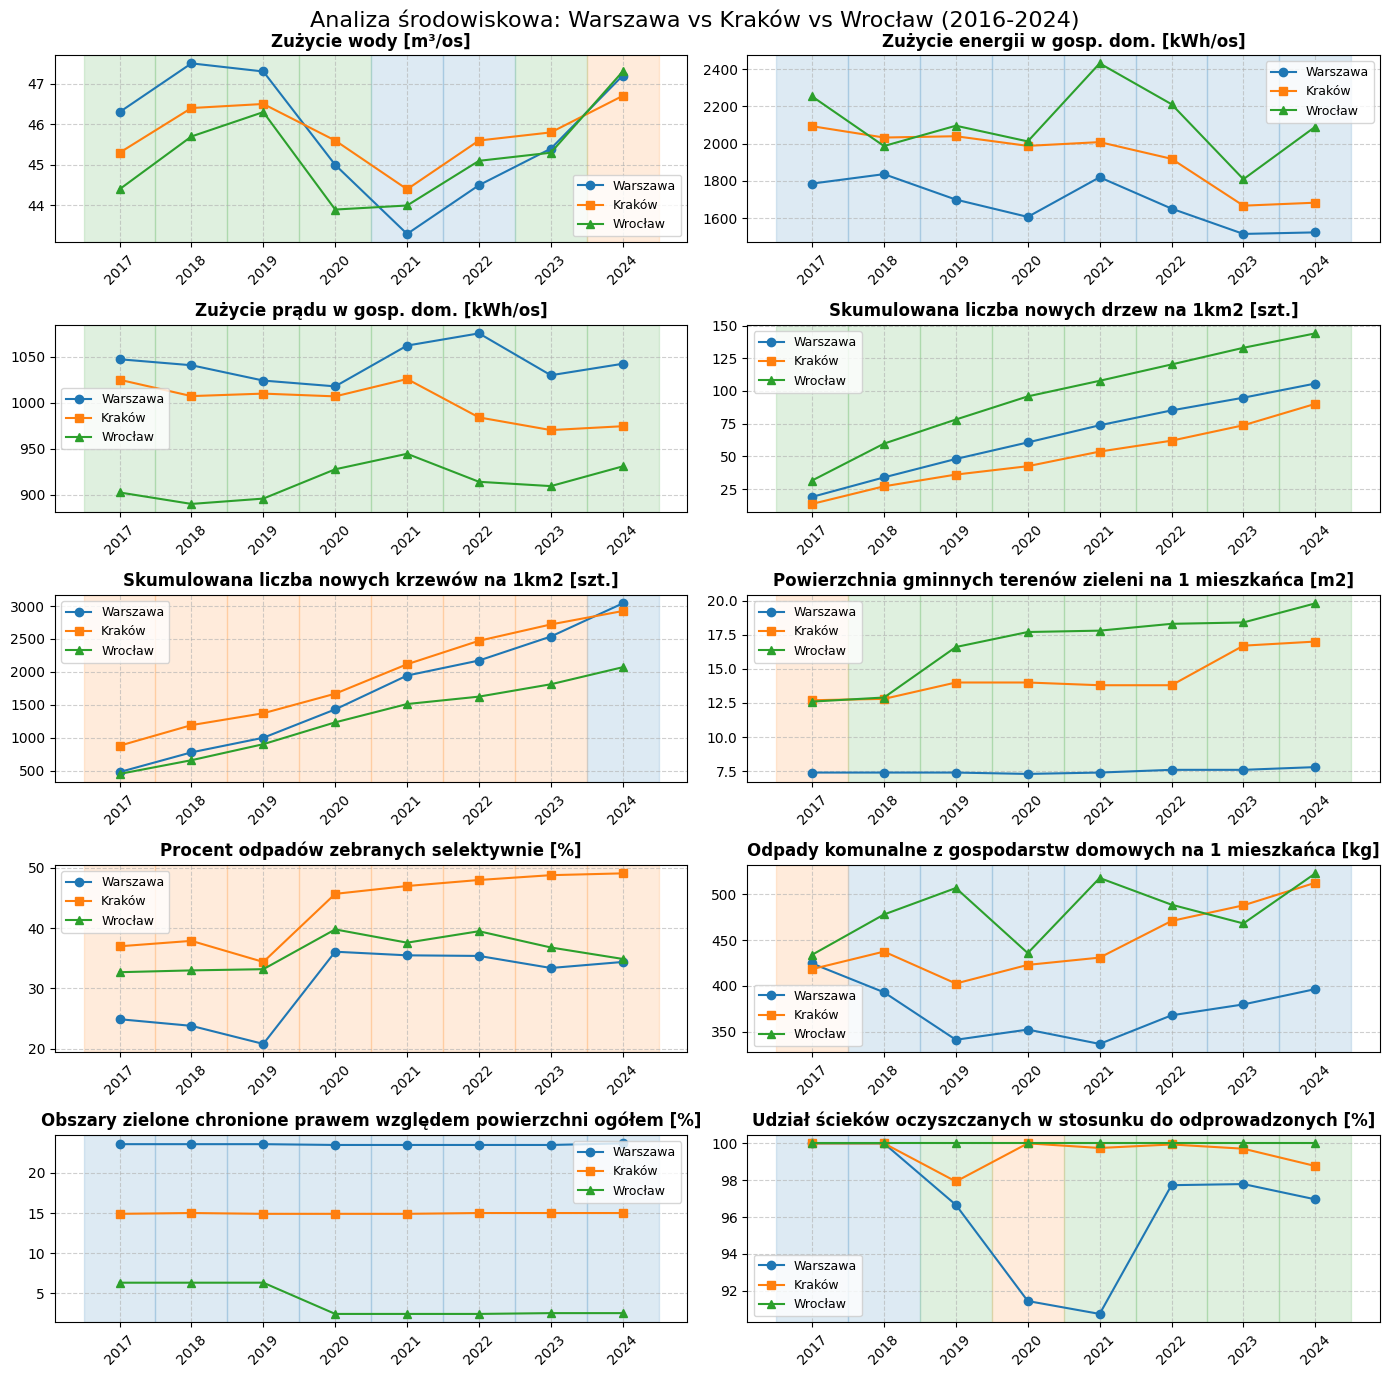

In [134]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14))
axes = axes.flatten()

colors = {
    'WAW': '#1f77b4',
    'KRK': '#ff7f0e',
    'WRC': '#2ca02c'
}

for i, (name, values) in enumerate(metrics.items()):
    ax = axes[i]

    years = values['WAW'].index
    x = np.arange(len(years))

    waw = values['WAW'].values
    krk = values['KRK'].values
    wrc = values['WRC'].values

    ax.plot(x, waw, label='Warszawa', color=colors['WAW'], marker='o')
    ax.plot(x, krk, label='Kraków', color=colors['KRK'], marker='s')
    ax.plot(x, wrc, label='Wrocław', color=colors['WRC'], marker='^')

    for j in range(len(x)):
        vals = {
            'WAW': waw[j],
            'KRK': krk[j],
            'WRC': wrc[j]
        }

        if values["Positive"]:
            best = max(vals, key=vals.get)
        else:
            best = min(vals, key=vals.get)

        ax.axvspan(j - 0.5, j + 0.5,
                   color=colors[best], alpha=0.15)

    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle('Analiza środowiskowa: Warszawa vs Kraków vs Wrocław (2016-2024)', fontsize=16)
plt.tight_layout()
plt.savefig('img/environmental_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [135]:
import seaborn as sns

In [136]:
rows = []
for year in allowed_years:
    for city in ['WAW', 'KRK', 'WRC']:
        row = {'City': city, 'Year': year}
        for metric_name, data in metrics.items():
            row[metric_name] = data[city][year]
        rows.append(row)

df = pd.DataFrame(rows).set_index(['City', 'Year'])

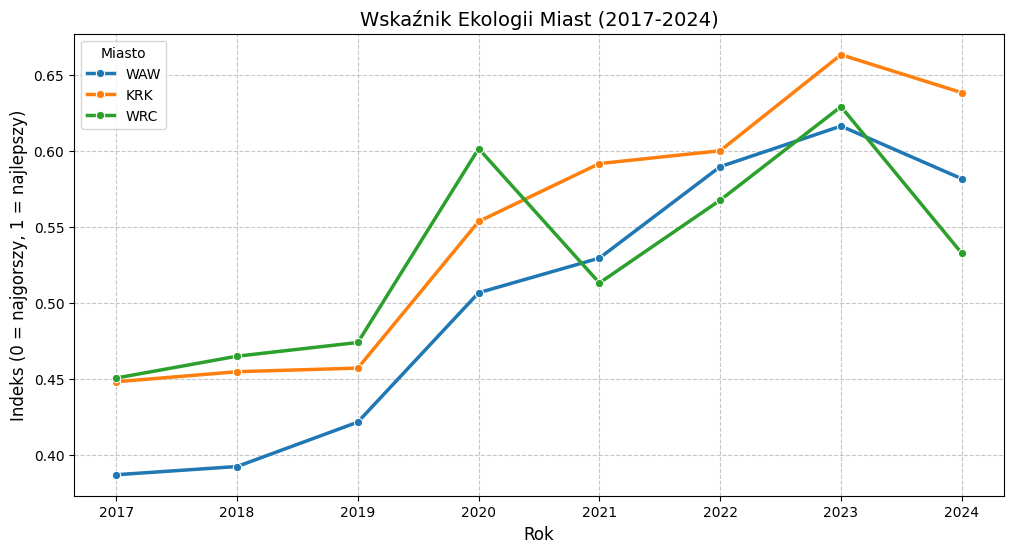

           EcoIndex
City Year          
WAW  2017  0.387099
KRK  2017  0.448237
WRC  2017  0.450689
WAW  2018  0.392494
KRK  2018  0.454835
WRC  2018  0.465056
WAW  2019  0.421713
KRK  2019  0.457207
WRC  2019  0.474052
WAW  2020  0.506773
KRK  2020  0.553638
WRC  2020  0.601533
WAW  2021  0.529549
KRK  2021  0.591701
WRC  2021  0.513186
WAW  2022  0.589664
KRK  2022  0.600138
WRC  2022  0.567646
WAW  2023  0.616355
KRK  2023  0.663279
WRC  2023  0.629153
WAW  2024  0.581725
KRK  2024  0.638341
WRC  2024  0.532732


In [137]:
df_norm = pd.DataFrame(index=df.index)

for col in df.columns:
    is_positive = metrics[col].get('Positive', True)
    min_val = df[col].min()
    max_val = df[col].max()
    
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)
    if not is_positive:
        df_norm[col] = 1 - df_norm[col]


df['EcoIndex'] = df_norm.mean(axis=1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df.reset_index(), x='Year', y='EcoIndex', hue='City', marker='o', linewidth=2.5)

plt.title('Wskaźnik Ekologii Miast (2017-2024)', fontsize=14)
plt.ylabel('Indeks (0 = najgorszy, 1 = najlepszy)', fontsize=12)
plt.xlabel('Rok', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Miasto')
plt.savefig('img/eco_index_comparison.png', dpi=300)
plt.show()

print(df[['EcoIndex']])